本文件用以将Kpass 转身板的电信号转化为力值信号

计算峰值数据和 Kpass 给出的峰值数据可能略有不同：
原因有二：
1. Kpass 本身的取最大值的方式有问题，可能选取的不是正确的最大值
2. 滤波会影响峰值

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import datetime

In [7]:
root_path = "/Users/wangshuaibo/Downloads/徐嘉余"

In [10]:
# 测力台参数
# 定义不同传感器的灵敏度(sensitivity)
# 参见 KpassSetUp.csv 


# 定义前台和水平面的夹角
angle = 10.2 # 每块测力台的数值不同，从测力台的 pdf 当中获取
theta_rad = np.deg2rad(angle) 
## 定义不同传感器的灵敏度(sensitivity)


sensitivity = {
    '抓手Z方向电压': 3.899,
    '抓手X方向电压': 1.842,
    
    '前台Y14电压': 3.861,
    '前台Y23电压': 3.861,

    '前台Z1电压': 3.611,
    '前台Z2电压': 3.611,
    '前台Z3电压': 3.611,
    '前台Z4电压': 3.611,

    "N/A_1": 1, # 1 为填补空缺，不用修改
    "N/A_2": 1, # 1 为填补空缺，不用修改

    '后台Y14电压': 3.864,
    '后台Y23电压': 3.864,
    
    '后台Z1电压': 3.657,
    '后台Z2电压': 3.657,
    '后台Z3电压': 3.657,
    '后台Z4电压': 3.657,
    
    "转身板x12": 4, 
    "转身板x34": 4,
    "转身板y14": 4,
    "转身板y23": 4,
    "转身板z1": 3.384,
    "转身板z2": 3.384,
    "转身板z3": 3.384,
    "转身板z4": 3.384,
}

只有转身板有 20180918 参数，其他为 20180423 数据，下为20180918数据，
    "转身板x12": 3.681, 
    "转身板x34": 3.681,
    "转身板y14": 3.681,
    "转身板y23": 3.681,
    "转身板z1": 3.384,
    "转身板z2": 3.384,
    "转身板z3": 3.384,
    "转身板z4": 3.384,

In [11]:
# 按照Kistler 工程师邮件中的说明，命名
head_list = ["抓手Z方向电压","抓手X方向电压",
             "前台Y14电压","前台Y23电压",
             "前台Z1电压","前台Z2电压","前台Z3电压","前台Z4电压",
             "N/A_1","N/A_2",
             "后台Y14电压","后台Y23电压",
             "后台Z1电压","后台Z2电压","后台Z3电压","后台Z4电压",
             
             "转身板x12","转身板x34","转身板y14","转身板y23",
             "转身板z1","转身板z2","转身板z3","转身板z4"]
usecols=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]

正在处理ad_230628164828.csv...
ad_230628164828.csv已经完成处理


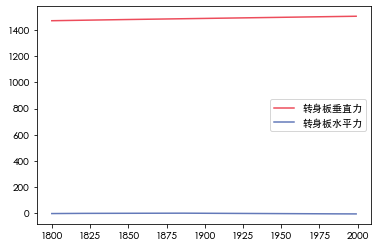

In [12]:
for file in os.listdir(root_path):
    file_path = os.path.join(root_path, file)
    if os.path.isdir(file_path):
            os.chdir(file_path)
            for file in os.listdir(file_path):
                if ".csv" in file and file.startswith("ad_"):
                    raw_data_fname = file
                    print("正在处理{}...".format(raw_data_fname))
                    processed_bae_fname, extension = os.path.splitext(file)
       
                    offset_data = pd.read_csv(raw_data_fname, skiprows=4, nrows=1,usecols=usecols, names=head_list) # 读取偏移量
                    voltage_data = pd.read_csv(raw_data_fname, skiprows=6, usecols=usecols, names=head_list) # 读取电压数据

                    
                    # 计算各个传感器的电压值
                    # 减去偏移量并将结果汇总到新的列，使用 pandas 广播功能
                    voltage_data_adjusted = voltage_data.sub(offset_data.iloc[0].T)
                    # 根据调整后的电压计算力值，使用 pandas 广播功能
                    Sen_Force = voltage_data_adjusted / pd.Series(sensitivity) * 1000
                    # 除使用广播的方式进行计算，还可以使用 apply 函数
                    #Sen_Force_apply = voltage_data_adjusted.apply(lambda x: x/ sensitivity[x.name] * 1000)
            
                    # 计算转身板的垂直力和水平力
                    # 先计算相对于测力台本身的数据


                    # 计算前后台的水平力和垂直力
                    # 先计算相对于测力台本身的数据
                    Plate_Force = pd.DataFrame()
                    Plate_Force['前台传感器水平力'] = Sen_Force['前台Y14电压'] + Sen_Force['前台Y23电压']
                    Plate_Force["前台传感器垂直力"] = Sen_Force['前台Z1电压'] + Sen_Force['前台Z2电压'] + Sen_Force['前台Z3电压'] + Sen_Force['前台Z4电压']
                    # 将传感器的力值转化到水平和垂直方向
                    Plate_Force['前台水平力'] =  Plate_Force["前台传感器垂直力"] * np.sin(theta_rad) + Plate_Force['前台传感器水平力'] * np.cos(theta_rad)
                    Plate_Force['前台垂直力'] =  Plate_Force["前台传感器垂直力"] * np.cos(theta_rad) - Plate_Force['前台传感器水平力'] * np.sin(theta_rad)
                    Plate_Force["前台合力"] = (Plate_Force["前台水平力"]**2 + Plate_Force["前台垂直力"]**2)**0.5

                    Plate_Force["后台传感器水平力"] = Sen_Force['后台Y14电压'] + Sen_Force['后台Y23电压']
                    Plate_Force['后台传感器垂直力'] = Sen_Force['后台Z1电压'] + Sen_Force['后台Z2电压'] + Sen_Force['后台Z3电压'] + Sen_Force['后台Z4电压']
                    Plate_Force['后台水平力'] =  Plate_Force["后台传感器垂直力"] * np.sin(theta_rad) + Plate_Force['后台传感器水平力'] * np.cos(theta_rad)
                    Plate_Force['后台垂直力'] =  Plate_Force["后台传感器垂直力"] * np.cos(theta_rad) - Plate_Force['后台传感器水平力'] * np.sin(theta_rad)
                    Plate_Force["后台合力"] = (Plate_Force["后台水平力"]**2 + Plate_Force["后台垂直力"]**2)**0.5

                    Plate_Force["抓手传感器水平力"] = Sen_Force['抓手X方向电压'] # Gx 为平行于水平方向
                    Plate_Force["抓手传感器垂直力"] = Sen_Force['抓手Z方向电压']  # Gz 为垂直于水平方向
                    Plate_Force["抓手水平力"] = Plate_Force["抓手传感器水平力"]
                    Plate_Force["抓手垂直力"] = Plate_Force["抓手传感器垂直力"] * -1

                    Plate_Force['转身板水平力'] = Sen_Force["转身板z1"] + Sen_Force["转身板z2"] + Sen_Force["转身板z3"] + Sen_Force["转身板z3"]
                    Plate_Force["转身板垂直力"] = -(Sen_Force["转身板x12"] + Sen_Force["转身板x34"])

                    # 此处计算前后台在水平方面和垂直方向的合力
                    Plate_Force["传感器方向水平合力"] = Plate_Force['前台传感器水平力'] + Plate_Force['后台传感器水平力']
                    Plate_Force["传感器方向垂直合力"] = Plate_Force['前台传感器垂直力'] + Plate_Force['后台传感器垂直力']
                    
                    # 将测力台垂直和水平力分解到大地水平方向和垂直方向
                    Plate_Force["水平力"] = Plate_Force["传感器方向垂直合力"] * np.sin(theta_rad) + Plate_Force["传感器方向水平合力"] * np.cos(theta_rad) + Plate_Force["抓手传感器水平力"]
                    Plate_Force["垂直力"] = Plate_Force["传感器方向垂直合力"] * np.cos(theta_rad) - Plate_Force["传感器方向水平合力"] * np.sin(theta_rad) + Plate_Force["抓手传感器垂直力"]

                    ## 对力值信号进行滤波
                    # 在根据测力台信号计算垂直和水平力之前，使用 10HZ 的低通滤波对测量信号进行数字平滑处理。
                    # ref：Mason, Bruce, Alison Alcock和John Fowlie. 《A Kinetic Analysis and Recommendations for Elite Swimmers Performing the Sprint Start》, 4, 2007.
                    # 武哥是在计算得到水平力之后进行滤波，此处与武哥保持一致，两种滤波方式相差不大
                    target_columns = ['前台合力','前台水平力','前台垂直力',
                                    '后台合力','后台水平力','后台垂直力',
                                    '抓手垂直力','抓手水平力',
                                    '垂直力','水平力',
                                    '转身板水平力',"转身板垂直力"]
                    

                    fs = 500 # 测力台采集频率为 500 Hz
                    n = 2 # 滤波器阶数
                    Wn = 10 / (fs / 2) # 计算归一化频率， 截止频率为  10 Hz，和 kPassSetup.csv 中的截断频率一致
                    b, a = signal.butter(n, Wn, 'low') # 低通滤波器
                    # 对选定的列进行滤波
                    filtered_data = Plate_Force[target_columns].apply(lambda column: signal.filtfilt(b, a, column))
                    
                    """
                    # 除以体重，对力值进行归一化处理(仅有转身板就无法除以体重）
                    # 计算运动员体重(单位:N) 
                    # 运动员静止站立时垂直
                    # 测力台会在发令枪响前 500 整数开始采集数据
                    weight_time = 500-1 # 枪响枪前会采集 500 个数据，这里默认为 500
                    Weight_N = Plate_Force.loc[0:weight_time,"垂直力"].mean()
                    normalized_data = filtered_data / Weight_N
                    """
                    normalized_data = filtered_data
                    current_time = datetime.datetime.now().strftime("%Y%m%d%H%M%S_")
                    excel_filename = current_time +  processed_bae_fname + ".xlsx"
                    normalized_data.to_excel(excel_filename,index=False)

                    # 设置字体，以便支持中文显示
                    plt.rcParams['font.sans-serif'] = ['Heiti TC']
                    plt.rcParams['font.family'] = ['Heiti TC']
                    plt.rcParams['axes.unicode_minus'] = False

                    # 指定水平力和垂直力的颜色
                    horizontal_force_color = '#6379b9'  # 蓝色
                    vertical_force_color = '#ed4c5b'    # 红色

                    # 绘制转身板水平力和转身板垂直力，分别为蓝色和红色
                    normalized_data.loc[1800:, ["转身板垂直力", "转身板水平力"]].plot(
                        color={"转身板垂直力": vertical_force_color, "转身板水平力": horizontal_force_color}
                    )

                    plot_filename = current_time +  processed_bae_fname + ".png"
                    # 显示图表
                    plt.savefig(plot_filename)

                    print(f"{file}已经完成处理")

## 回收站

In [ ]:
for file in os.listdir(root_path):
    file_path = os.path.join(root_path, file)
    if os.path.isdir(file_path):
            os.chdir(file_path)
            for file in os.listdir(file_path):
                if ".csv" in file:
                    raw_data_fname = file
                elif ".pdf" in file and "._" not in file: #去除掉 Mac 当中的隐藏文件
                    processed_bae_fname, extension = os.path.splitext(file)
                    #print(processed_bae_fname)                    
                offset_data = pd.read_csv(raw_data_fname, skiprows=4, nrows=1,usecols=usecols, names=head_list) # 读取偏移量
                voltage_data = pd.read_csv(raw_data_fname, skiprows=6, usecols=usecols, names=head_list) # 读取电压数据

                
                # 计算各个传感器的电压值
                # 减去偏移量并将结果汇总到新的列，使用 pandas 广播功能
                voltage_data_adjusted = voltage_data.sub(offset_data.iloc[0].T)
                # 根据调整后的电压计算力值，使用 pandas 广播功能
                Sen_Force = voltage_data_adjusted / pd.Series(sensitivity) * 1000
                # 除使用广播的方式进行计算，还可以使用 apply 函数
                #Sen_Force_apply = voltage_data_adjusted.apply(lambda x: x/ sensitivity[x.name] * 1000)
          
                # 计算转身板的垂直力和水平力
                # 先计算相对于测力台本身的数据


                # 计算前后台的水平力和垂直力
                # 先计算相对于测力台本身的数据
                Plate_Force = pd.DataFrame()
                Plate_Force['前台传感器水平力'] = Sen_Force['前台Y14电压'] + Sen_Force['前台Y23电压']
                Plate_Force["前台传感器垂直力"] = Sen_Force['前台Z1电压'] + Sen_Force['前台Z2电压'] + Sen_Force['前台Z3电压'] + Sen_Force['前台Z4电压']
                # 将传感器的力值转化到水平和垂直方向
                Plate_Force['前台水平力'] =  Plate_Force["前台传感器垂直力"] * np.sin(theta_rad) + Plate_Force['前台传感器水平力'] * np.cos(theta_rad)
                Plate_Force['前台垂直力'] =  Plate_Force["前台传感器垂直力"] * np.cos(theta_rad) - Plate_Force['前台传感器水平力'] * np.sin(theta_rad)
                Plate_Force["前台合力"] = (Plate_Force["前台水平力"]**2 + Plate_Force["前台垂直力"]**2)**0.5

                Plate_Force["后台传感器水平力"] = Sen_Force['后台Y14电压'] + Sen_Force['后台Y23电压']
                Plate_Force['后台传感器垂直力'] = Sen_Force['后台Z1电压'] + Sen_Force['后台Z2电压'] + Sen_Force['后台Z3电压'] + Sen_Force['后台Z4电压']
                Plate_Force['后台水平力'] =  Plate_Force["后台传感器垂直力"] * np.sin(theta_rad) + Plate_Force['后台传感器水平力'] * np.cos(theta_rad)
                Plate_Force['后台垂直力'] =  Plate_Force["后台传感器垂直力"] * np.cos(theta_rad) - Plate_Force['后台传感器水平力'] * np.sin(theta_rad)
                Plate_Force["后台合力"] = (Plate_Force["后台水平力"]**2 + Plate_Force["后台垂直力"]**2)**0.5

                Plate_Force["抓手传感器水平力"] = Sen_Force['抓手X方向电压'] # Gx 为平行于水平方向
                Plate_Force["抓手传感器垂直力"] = Sen_Force['抓手Z方向电压']  # Gz 为垂直于水平方向
                Plate_Force["抓手水平力"] = Plate_Force["抓手传感器水平力"]
                Plate_Force["抓手垂直力"] = Plate_Force["抓手传感器垂直力"] * -1

                Plate_Force['转身板水平力'] = Sen_Force["转身板z1"] + Sen_Force["转身板z2"] + Sen_Force["转身板z3"] + Sen_Force["转身板z3"]
                Plate_Force["转身板垂直力"] = -(Sen_Force["转身板x12"] + Sen_Force["转身板x34"])

                # 此处计算前后台在水平方面和垂直方向的合力
                Plate_Force["传感器方向水平合力"] = Plate_Force['前台传感器水平力'] + Plate_Force['后台传感器水平力']
                Plate_Force["传感器方向垂直合力"] = Plate_Force['前台传感器垂直力'] + Plate_Force['后台传感器垂直力']
                
                # 将测力台垂直和水平力分解到大地水平方向和垂直方向
                Plate_Force["水平力"] = Plate_Force["传感器方向垂直合力"] * np.sin(theta_rad) + Plate_Force["传感器方向水平合力"] * np.cos(theta_rad) + Plate_Force["抓手传感器水平力"]
                Plate_Force["垂直力"] = Plate_Force["传感器方向垂直合力"] * np.cos(theta_rad) - Plate_Force["传感器方向水平合力"] * np.sin(theta_rad) + Plate_Force["抓手传感器垂直力"]

                ## 对力值信号进行滤波
                # 在根据测力台信号计算垂直和水平力之前，使用 10HZ 的低通滤波对测量信号进行数字平滑处理。
                # ref：Mason, Bruce, Alison Alcock和John Fowlie. 《A Kinetic Analysis and Recommendations for Elite Swimmers Performing the Sprint Start》, 4, 2007.
                # 武哥是在计算得到水平力之后进行滤波，此处与武哥保持一致，两种滤波方式相差不大
                target_columns = ['前台合力','前台水平力','前台垂直力',
                                '后台合力','后台水平力','后台垂直力',
                                '抓手垂直力','抓手水平力',
                                '垂直力','水平力',
                                '转身板水平力',"转身板垂直力"]

                fs = 500 # 测力台采集频率为 500 Hz
                n = 2 # 滤波器阶数
                Wn = 10 / (fs / 2) # 计算归一化频率， 截止频率为  10 Hz
                b, a = signal.butter(n, Wn, 'low') # 低通滤波器
                # 对选定的列进行滤波
                filtered_data = Plate_Force[target_columns].apply(lambda column: signal.filtfilt(b, a, column))

                
                """
                # 除以体重，对力值进行归一化处理(仅有转身板就无法除以体重）
                # 计算运动员体重(单位:N) 
                # 运动员静止站立时垂直
                # 测力台会在发令枪响前 500 整数开始采集数据
                weight_time = 500-1 # 枪响枪前会采集 500 个数据，这里默认为 500
                Weight_N = Plate_Force.loc[0:weight_time,"垂直力"].mean()
                normalized_data = filtered_data / Weight_N
                """
                normalized_data = filtered_data
                current_time = datetime.datetime.now().strftime("%Y%m%d%H%M%S_")
                excel_filename = current_time +  processed_bae_fname + ".xlsx"
                normalized_data.to_excel(excel_filename,index=False)

                # 设置字体，以便支持中文显示
                plt.rcParams['font.sans-serif'] = ['Heiti TC']
                plt.rcParams['font.family'] = ['Heiti TC']
                plt.rcParams['axes.unicode_minus'] = False

                # 指定水平力和垂直力的颜色
                horizontal_force_color = '#6379b9'  # 蓝色
                vertical_force_color = '#ed4c5b'    # 红色

                # 绘制转身板水平力和转身板垂直力，分别为蓝色和红色
                normalized_data.loc[1800:, ["转身板垂直力", "转身板水平力"]].plot(
                    color={"转身板垂直力": vertical_force_color, "转身板水平力": horizontal_force_color}
                )

                plot_filename = current_time +  processed_bae_fname + ".png"
                # 显示图表
                plt.savefig(plot_filename)

                print(f"{file}已经完成处理")